# BACE: Standard-SEG vs TAME (Tri-Modal MoE)

Dieses Notebook vergleicht auf **demselben BACE Scaffold-Split** drei Modelle:
1. **Standard SEG** (Graph + Text)
2. **TAME** (Graph + Text + RDKit-Deskriptoren mit element-wise MoE-Gating)
3. **TAME (Stage-1 init)**: TAME, dessen Graph-Encoder aus einem Stage-1-pretrained ChebNet initialisiert wird

Alle Modelle verwenden dieselben Text-Embeddings aus dem Cache.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

import deepchem as dc
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

print(f'Workspace root: {workspace_root}')
print(f'Device: {device}')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace root: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
def to_binary01(y):
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    y = np.where(np.isfinite(y), y, np.nan)
    if np.isnan(y).any():
        raise ValueError('Labels contain NaN values.')

    uniq = np.unique(y)
    if set(np.round(uniq).tolist()).issubset({0.0, 1.0}):
        return y.astype(np.float32)
    if set(np.round(uniq).tolist()).issubset({-1.0, 1.0}):
        return (y > 0).astype(np.float32)

    raise ValueError(f'Unsupported binary labels: {uniq}')

def find_best_threshold(y_true, y_pred_proba):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred_proba = np.asarray(y_pred_proba, dtype=np.float32).reshape(-1)
    mask = np.isfinite(y_pred_proba)
    y_true = y_true[mask]
    y_pred_proba = np.clip(y_pred_proba[mask], 0.0, 1.0)

    best_thr = 0.5
    best_f1 = -1.0
    best_acc = -1.0

    for thr in np.linspace(0.05, 0.95, 181):
        y_hat = (y_pred_proba >= thr).astype(np.float32)
        tp = float(np.sum((y_hat == 1) & (y_true == 1)))
        tn = float(np.sum((y_hat == 0) & (y_true == 0)))
        fp = float(np.sum((y_hat == 1) & (y_true == 0)))
        fn = float(np.sum((y_hat == 0) & (y_true == 1)))
        acc = float((tp + tn) / max(tp + tn + fp + fn, 1.0))
        precision = float(tp / max(tp + fp, 1.0))
        recall = float(tp / max(tp + fn, 1.0))
        f1 = float(2.0 * precision * recall / max(precision + recall, 1e-12))

        if (f1 > best_f1) or (np.isclose(f1, best_f1) and acc > best_acc):
            best_f1 = f1
            best_acc = acc
            best_thr = float(thr)

    return best_thr

def classification_metrics(y_true, y_pred_proba, threshold=0.5):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred_proba = np.asarray(y_pred_proba, dtype=np.float32).reshape(-1)
    y_pred_proba = np.clip(y_pred_proba, 0.0, 1.0)
    mask = np.isfinite(y_pred_proba)
    y_true = y_true[mask]
    y_pred_proba = y_pred_proba[mask]
    y_pred = (y_pred_proba >= threshold).astype(np.float32)

    return {
        'roc_auc': float(roc_auc_score(y_true, y_pred_proba)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue
        all_desc = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_desc.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))
    return np.vstack(rows).astype(np.float32), desc_names

def impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(train_X, axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)

In [3]:
tasks, datasets, _ = dc.molnet.load_bace_classification(featurizer='ECFP', splitter='scaffold')
train_dc, valid_dc, test_dc = datasets

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

train_y_arr = to_binary01(train_dc.y)
valid_y_arr = to_binary01(valid_dc.y)
test_y_arr = to_binary01(test_dc.y)

train_y = train_y_arr.tolist()
valid_y = valid_y_arr.tolist()

emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'binding_fast_text_embeddings_compact.npz'
if not npz_path.exists():
    raise FileNotFoundError(f'Embedding cache not found: {npz_path}')

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = torch.from_numpy(seg_cache.get_batch(all_smiles)).float()
n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = all_emb[:n_train]
valid_emb = all_emb[n_train:n_train + n_valid]
test_emb = all_emb[n_train + n_valid:]

d_train, desc_names = rdkit_descriptor_matrix(train_smiles)
d_valid, _ = rdkit_descriptor_matrix(valid_smiles)
d_test, _ = rdkit_descriptor_matrix(test_smiles)
d_train, d_valid, d_test = impute_with_train_median(d_train, d_valid, d_test)

print(f'BACE sizes -> train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}')
print(f'Class balance -> train={train_y_arr.mean():.3f}, val={valid_y_arr.mean():.3f}, test={test_y_arr.mean():.3f}')
print(f'Text embedding dim: {all_emb.shape[1]} | Descriptor dim: {d_train.shape[1]}')

Loading embeddings from binding_fast_text_embeddings_compact.npz...
  Loaded 1513 entries, dim=3072
  Memory mode: mapped
BACE sizes -> train=1210, val=151, test=152
Class balance -> train=0.426, val=0.556, test=0.605
Text embedding dim: 3072 | Descriptor dim: 217


In [4]:
SEG_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'text_proj_init': 'xavier',
    'text_proj_init_gain': 0.1,
    'freeze_text_proj': False,
    'dropout': 0.3,
    'fusion_dropout': 0.3,
    'head_dropout': 0.5,
    'head_type': 'mlp',
    'head_hidden_dim': 32,
    'learning_rate': 5e-3,
    'weight_decay': 1e-1,
    'batch_size': 64,
    'num_epochs': 200,
    'patience': 30,
    'scheduler': 'cosine',
    'scheduler_patience': 5,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': None,
}

TAME_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion_hidden_dim': 64,
    # Stronger regularization to reduce rapid overfitting on BACE split.
    'projection_dropout': 0.35,
    'router_dropout': 0.45,
    'head_hidden_dim': 64,
    'head_dropout': 0.4,
    'learning_rate': 3e-4,
    'weight_decay': 1e-1,
    'gate_balance_weight': 0.02,
    'desc_modality_dropout': 0.35,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 120,
    'patience': 12,
}

def make_seg_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='classification',
        num_tasks=1,
        hidden_channels=SEG_FIT_KWARGS['hidden_channels'],
        K=SEG_FIT_KWARGS['K'],
        num_layers=SEG_FIT_KWARGS['num_layers'],
        dropout=SEG_FIT_KWARGS['dropout'],
        pool=SEG_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_FIT_KWARGS['fusion'],
        fusion_dim=SEG_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_FIT_KWARGS['head_dropout'],
        add_hydrogens=False,
    )

def make_tame_config(text_embedding_dim):
    return TAMEPredictorConfig(
        task='classification',
        hidden_channels=TAME_FIT_KWARGS['hidden_channels'],
        K=TAME_FIT_KWARGS['K'],
        num_layers=TAME_FIT_KWARGS['num_layers'],
        pool=TAME_FIT_KWARGS['pool'],
        text_embedding_dim=int(text_embedding_dim),
        fusion_hidden_dim=TAME_FIT_KWARGS['fusion_hidden_dim'],
        projection_dropout=TAME_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def resolve_stage1_pretrain_checkpoint():
    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    alias = ckpt_dir / 'cheb_foundation_pretrain_stage1.pt'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    pattern = (
        f"cheb_foundation_stage1__h{TAME_FIT_KWARGS['hidden_channels']}__"
        f"L{TAME_FIT_KWARGS['num_layers']}__"
        f"K{TAME_FIT_KWARGS['K']}__*.pt"
    )
    candidates = sorted(
        [p for p in ckpt_dir.glob(pattern) if '__fallback__' not in p.name],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if candidates:
        return candidates[0]
    if alias.exists():
        return alias
    raise FileNotFoundError('No stage1 pretraining checkpoint found for TAME init.')

def load_stage1_encoder_state(ckpt_path):
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if not isinstance(payload, dict):
        raise RuntimeError('Invalid checkpoint payload format.')

    stage = payload.get('pretraining_stage', None)
    if stage != 'stage1_node':
        raise RuntimeError(
            f"Expected stage1 checkpoint (pretraining_stage='stage1_node'), got {stage!r}"
        )

    model_state = payload.get('model_state_dict', {})
    enc_state = {k.replace('encoder.', '', 1): v for k, v in model_state.items() if k.startswith('encoder.')}
    if not enc_state:
        raise RuntimeError('Checkpoint does not contain encoder.* weights.')

    print(f'Loaded stage1 encoder state from: {Path(ckpt_path).resolve()}')
    return enc_state

In [5]:
seg = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
seg_hist = seg.fit(
    smiles_list=train_smiles,
    labels=train_y,
    val_smiles=valid_smiles,
    val_labels=valid_y,
    text_embeddings=train_emb,
    val_text_embeddings=valid_emb,
    num_epochs=SEG_FIT_KWARGS['num_epochs'],
    batch_size=SEG_FIT_KWARGS['batch_size'],
    learning_rate=SEG_FIT_KWARGS['learning_rate'],
    weight_decay=SEG_FIT_KWARGS['weight_decay'],
    patience=SEG_FIT_KWARGS['patience'],
    scheduler=SEG_FIT_KWARGS['scheduler'],
    scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
    scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
    min_lr=SEG_FIT_KWARGS['min_lr'],
    grad_clip=SEG_FIT_KWARGS['grad_clip'],
    seed=seed,
    verbose=True,
)

seg_best_val = float(np.min(seg_hist['val_loss']))
seg_valid_proba = seg.predict_batch(valid_smiles, text_embeddings=valid_emb)
seg_thr = find_best_threshold(valid_y_arr, seg_valid_proba)
seg_test_proba = seg.predict_batch(test_smiles, text_embeddings=test_emb)
seg_metrics = classification_metrics(test_y_arr, seg_test_proba, threshold=seg_thr)

print('SEG threshold:', seg_thr)
print('SEG metrics:', seg_metrics)

Pre-computing molecular graphs for 1210 molecules...
Pre-computed 1210/1210 valid graphs
Pre-computing molecular graphs for 151 molecules...
Pre-computed 151/151 valid graphs
Training SEGPredictor on 1210 molecules...
Task: classification
Validation set: 151 molecules
Fusion method: cross_mha
LR scheduler: cosine
Epoch 001 | Train Loss: 0.6923 | Val BCE: 0.7007 | LR: 5.00e-03
Epoch 005 | Train Loss: 0.6854 | Val BCE: 0.7287 | LR: 4.99e-03
Epoch 010 | Train Loss: 0.6826 | Val BCE: 0.7286 | LR: 4.97e-03
Epoch 015 | Train Loss: 0.6826 | Val BCE: 0.7189 | LR: 4.93e-03
Epoch 020 | Train Loss: 0.6822 | Val BCE: 0.7201 | LR: 4.88e-03
Epoch 025 | Train Loss: 0.6835 | Val BCE: 0.7200 | LR: 4.81e-03
Epoch 030 | Train Loss: 0.6829 | Val BCE: 0.7206 | LR: 4.73e-03
Early stopping at epoch 34
Training complete! Best Val BCE: 0.6951
SEG threshold: 0.05
SEG metrics: {'roc_auc': 0.40144927536231884, 'accuracy': 0.6052631578947368, 'f1': 0.7540983606557377}


In [6]:
# TAME baseline (random initialization)
tame = TAMEPredictor(config=make_tame_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
tame_hist = tame.fit(
    smiles_list=train_smiles,
    labels=train_y,
    val_smiles=valid_smiles,
    val_labels=valid_y,
    text_embeddings=train_emb.numpy(),
    val_text_embeddings=valid_emb.numpy(),
    descriptor_features=d_train,
    val_descriptor_features=d_valid,
    num_epochs=TAME_FIT_KWARGS['num_epochs'],
    batch_size=TAME_FIT_KWARGS['batch_size'],
    learning_rate=TAME_FIT_KWARGS['learning_rate'],
    weight_decay=TAME_FIT_KWARGS['weight_decay'],
    patience=TAME_FIT_KWARGS['patience'],
    seed=seed,
    verbose=True,
)

tame_best_val = float(np.min(tame_hist['val_loss']))
tame_valid_proba = tame.predict_batch(valid_smiles, text_embeddings=valid_emb.numpy(), descriptor_features=d_valid)
tame_thr = find_best_threshold(valid_y_arr, tame_valid_proba)
tame_test_proba = tame.predict_batch(test_smiles, text_embeddings=test_emb.numpy(), descriptor_features=d_test)
tame_metrics = classification_metrics(test_y_arr, tame_test_proba, threshold=tame_thr)

print('TAME threshold:', tame_thr)
print('TAME metrics:', tame_metrics)

# TAME with Stage-1-pretrained Cheb encoder initialization
stage1_ckpt = resolve_stage1_pretrain_checkpoint()
stage1_encoder_state = load_stage1_encoder_state(stage1_ckpt)

tame_stage1_init = TAMEPredictor(config=make_tame_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
tame_stage1_hist = tame_stage1_init.fit(
    smiles_list=train_smiles,
    labels=train_y,
    val_smiles=valid_smiles,
    val_labels=valid_y,
    text_embeddings=train_emb.numpy(),
    val_text_embeddings=valid_emb.numpy(),
    descriptor_features=d_train,
    val_descriptor_features=d_valid,
    num_epochs=TAME_FIT_KWARGS['num_epochs'],
    batch_size=TAME_FIT_KWARGS['batch_size'],
    learning_rate=TAME_FIT_KWARGS['learning_rate'],
    weight_decay=TAME_FIT_KWARGS['weight_decay'],
    patience=TAME_FIT_KWARGS['patience'],
    seed=seed,
    verbose=True,
    init_encoder_state=stage1_encoder_state,
 )

tame_stage1_best_val = float(np.min(tame_stage1_hist['val_loss']))
tame_stage1_valid_proba = tame_stage1_init.predict_batch(
    valid_smiles, text_embeddings=valid_emb.numpy(), descriptor_features=d_valid
)
tame_stage1_thr = find_best_threshold(valid_y_arr, tame_stage1_valid_proba)
tame_stage1_test_proba = tame_stage1_init.predict_batch(
    test_smiles, text_embeddings=test_emb.numpy(), descriptor_features=d_test
)
tame_stage1_metrics = classification_metrics(test_y_arr, tame_stage1_test_proba, threshold=tame_stage1_thr)

print('TAME Stage1-init threshold:', tame_stage1_thr)
print('TAME Stage1-init metrics:', tame_stage1_metrics)

Descriptor preprocessing enabled (winsor q=[0.010, 0.990], standardize=True)
Epoch 001 | train=0.681325 | val=0.712370 | gates G/T/D=0.329/0.337/0.334
Epoch 005 | train=0.541488 | val=0.688430 | gates G/T/D=0.263/0.297/0.440
Epoch 010 | train=0.488491 | val=0.637569 | gates G/T/D=0.253/0.327/0.420
Epoch 015 | train=0.396448 | val=0.725985 | gates G/T/D=0.276/0.328/0.396
Epoch 020 | train=0.365335 | val=0.794876 | gates G/T/D=0.291/0.334/0.375
Early stopping at epoch 22
TAME threshold: 0.05
TAME metrics: {'roc_auc': 0.828623188405797, 'accuracy': 0.743421052631579, 'f1': 0.7979274611398963}
Loaded stage1 encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-400000.pt
Descriptor preprocessing enabled (winsor q=[0.010, 0.990], standardize=True)
Initialized TAME encoder from external checkpoint state
Epoch 001 | train=0.684161 | val=0.710602 | gates G/T/D=0.333/0.333/0.3

,model,threshold,best_val_loss,roc_auc,accuracy,f1
0,tame_trimodal_moe_stage1_init,0.17,0.620285,0.850543,0.789474,0.818182
1,tame_trimodal_moe,0.05,0.637569,0.828623,0.743421,0.797927
2,seg_standard,0.05,0.695140,0.401449,0.605263,0.754098


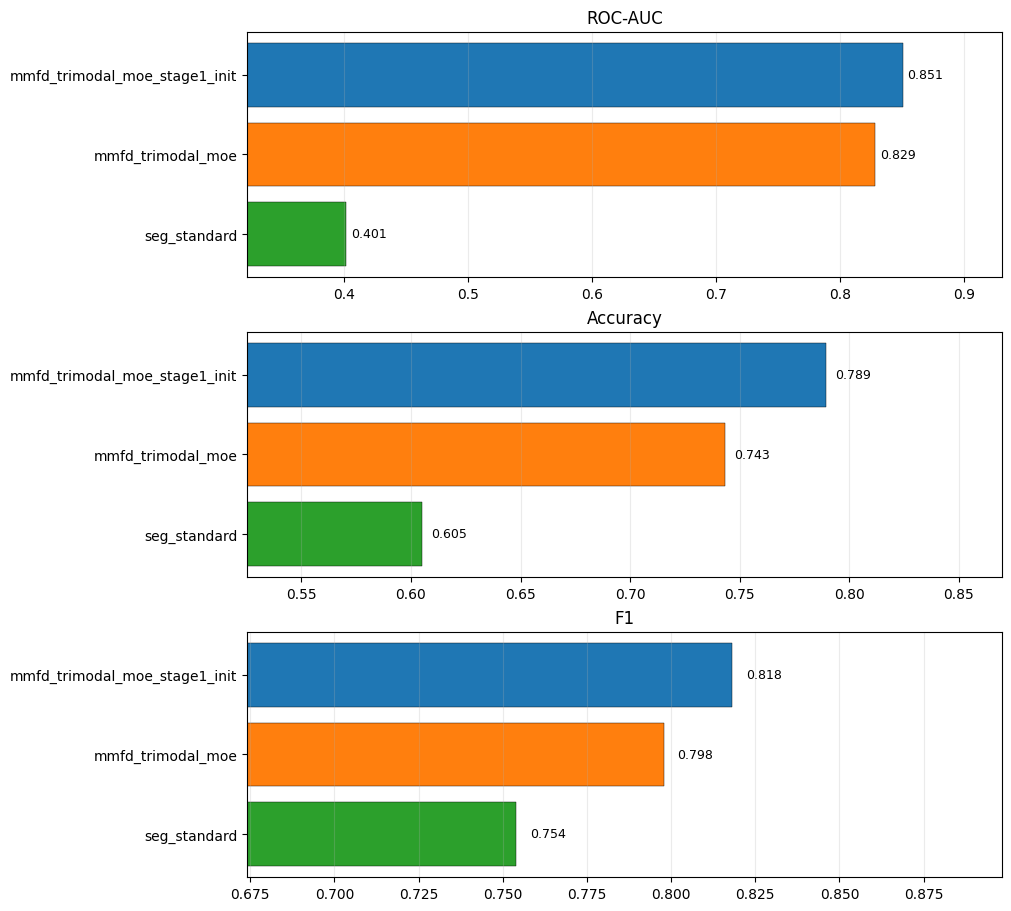

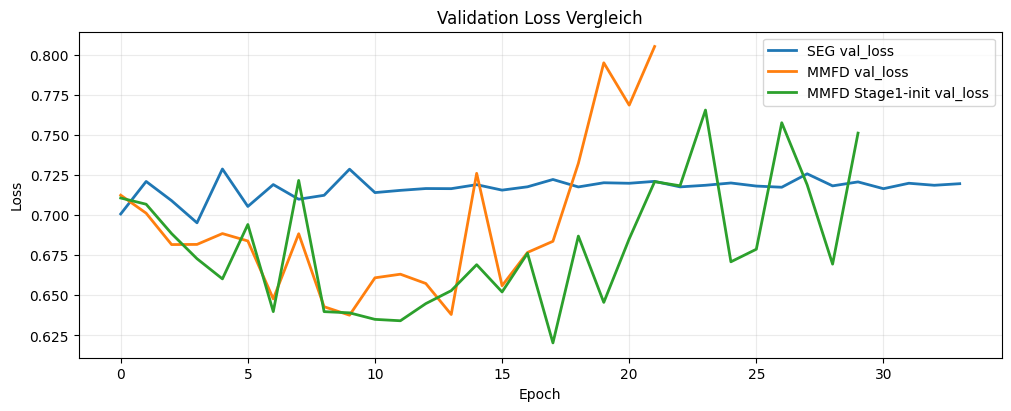

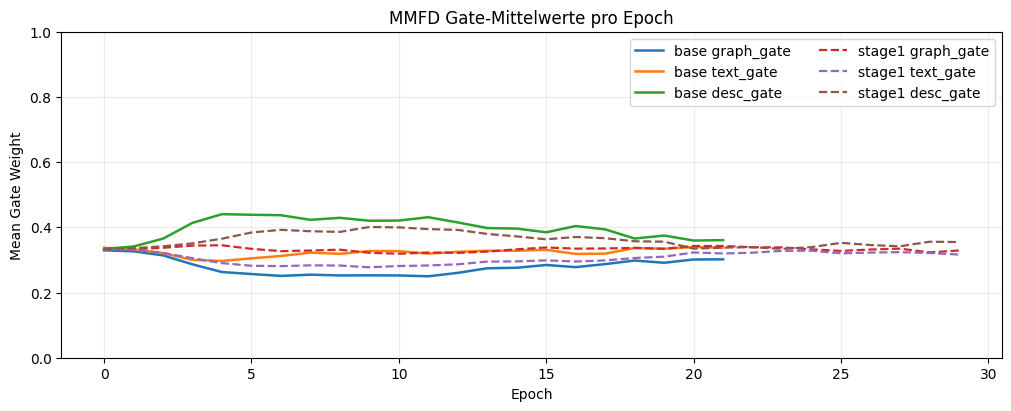

Saved comparison CSV to: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_seg_vs_tame_comparison.csv


In [7]:
comparison_df = pd.DataFrame([
    {'model': 'seg_standard', 'threshold': seg_thr, 'best_val_loss': seg_best_val, **seg_metrics},
    {'model': 'tame_trimodal_moe', 'threshold': tame_thr, 'best_val_loss': tame_best_val, **tame_metrics},
    {'model': 'tame_trimodal_moe_stage1_init', 'threshold': tame_stage1_thr, 'best_val_loss': tame_stage1_best_val, **tame_stage1_metrics},
])
comparison_df = comparison_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(comparison_df)

metrics_to_plot = ['roc_auc', 'accuracy', 'f1']
titles = ['ROC-AUC', 'Accuracy', 'F1']
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(3, 1, figsize=(10, 9), constrained_layout=True)
for ax, metric_name, title in zip(axes, metrics_to_plot, titles):
    values = comparison_df[metric_name].values
    y = np.arange(len(comparison_df))
    bars = ax.barh(y, values, color=palette[:len(values)], edgecolor='black', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(comparison_df['model'])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)
    xmin = max(0.0, float(np.min(values) - 0.08))
    xmax = min(1.0, float(np.max(values) + 0.08))
    ax.set_xlim(xmin, xmax)
    for bar, v in zip(bars, values):
        ax.text(v + 0.004, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center', fontsize=9)

plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
ax.plot(seg_hist.get('val_loss', []), label='SEG val_loss', linewidth=2)
ax.plot(tame_hist.get('val_loss', []), label='TAME val_loss', linewidth=2)
ax.plot(tame_stage1_hist.get('val_loss', []), label='TAME Stage1-init val_loss', linewidth=2)
ax.set_title('Validation Loss Vergleich')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

if all(k in tame_hist for k in ['graph_gate', 'text_gate', 'desc_gate']):
    fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
    ax.plot(tame_hist['graph_gate'], label='base graph_gate', linewidth=1.8)
    ax.plot(tame_hist['text_gate'], label='base text_gate', linewidth=1.8)
    ax.plot(tame_hist['desc_gate'], label='base desc_gate', linewidth=1.8)
    if all(k in tame_stage1_hist for k in ['graph_gate', 'text_gate', 'desc_gate']):
        ax.plot(tame_stage1_hist['graph_gate'], label='stage1 graph_gate', linewidth=1.6, linestyle='--')
        ax.plot(tame_stage1_hist['text_gate'], label='stage1 text_gate', linewidth=1.6, linestyle='--')
        ax.plot(tame_stage1_hist['desc_gate'], label='stage1 desc_gate', linewidth=1.6, linestyle='--')
    ax.set_title('TAME Gate-Mittelwerte pro Epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Gate Weight')
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.25)
    ax.legend(ncol=2)
    plt.show()

out_csv = workspace_root / 'benchmarking' / 'results' / 'bace_seg_vs_tame_comparison.csv'
comparison_df.to_csv(out_csv, index=False)
print(f'Saved comparison CSV to: {out_csv}')